# EVOLUTION D'INDICATEURS COVID AVEC MATPLOTLIB

In [4]:
# Initialisation
%matplotlib inline
import matplotlib.pyplot as plt

In [14]:
# On collecte les données d'hospitalisation et on les agrèg par jour
import pandas as pd
rep="C:/Users/dgr/OneDrive - Publicis Groupe/R&D/2020/covid19/donnees/donneesFR/"
#hospFR = pd.read_csv(rep+"donnees-hospitalieres-covid19-2020-04-06-19h00.csv",sep=';',error_bad_lines=False)

hospFR = pd.read_csv("https://www.data.gouv.fr/fr/datasets/r/63352e38-d353-4b54-bfd1-f1b3ee1cabd7",sep=';',error_bad_lines=False)

# les donnée sont pour hospitalisation et réa l'état par jour, ce n'est pas un cumul, pour les retours et les dc oui
hospFR=hospFR[hospFR.sexe==0]
hospFR.dtypes
hospFR.jour=pd.to_datetime(hospFR.jour,infer_datetime_format=True)
hospFRagg=hospFR.groupby(['jour'])['hosp','rea','rad','dc'].sum()
hospFRagg.columns=['hospitalisations','reanimations','retours','deces']

# les hospitalisations sont l'état chaque jour, si on ajoute retours et déces on a le cumul dhosp depuis le debut
hospFRagg['hospitalisationsBRUT']=hospFRagg['hospitalisations']+hospFRagg['retours']+hospFRagg['deces']

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:12: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  if sys.path[0] == '':


In [3]:
# Examinons les données
# l'index est le jour
hospFRagg.head()

,hospitalisations,reanimations,retours,deces,hospitalisationsBRUT
jour,,,,,
2020-03-18,2972,771,816,218,4006
2020-03-19,4073,1002,1180,327,5580
2020-03-20,5226,1297,1587,450,7263
2020-03-21,5900,1453,1811,525,8236
2020-03-22,6954,1674,2117,632,9703


Text(0, 0.5, 'Cas COVID FR Hôpital')

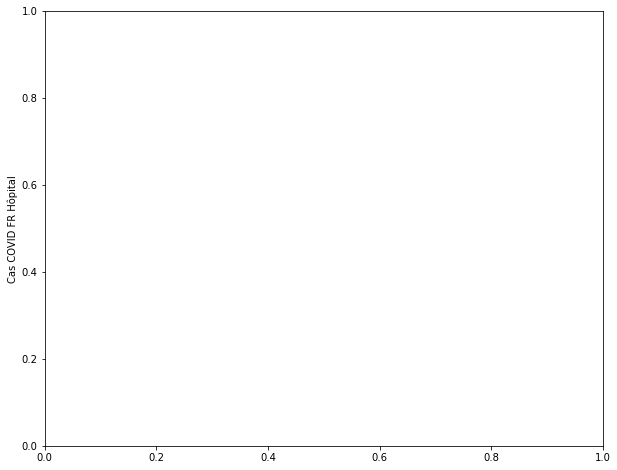

In [16]:
fig,ax=plt.subplots(figsize=(10, 8))
ax.set_ylabel('Cas COVID FR Hôpital')
#ax.set_yscale('log')


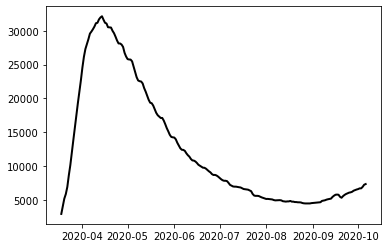

In [17]:
plt.plot(hospFRagg['hospitalisations'], color='black',lw=2, label = 'état des hospitalisations en t')

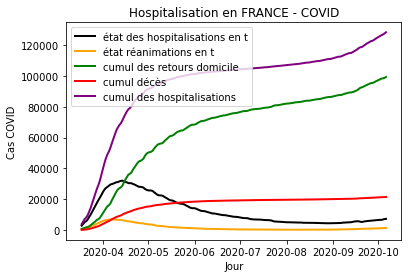

In [19]:
plt.plot(hospFRagg['hospitalisations'], color='black',lw=2, label = 'état des hospitalisations en t')
plt.plot(hospFRagg['reanimations'], color='orange',lw=2, label = 'état réanimations en t')
plt.plot(hospFRagg['retours'], color='green',lw=2, label = 'cumul des retours domicile')
plt.plot(hospFRagg['deces'], color='red',lw=2, label = 'cumul décès')
plt.plot(hospFRagg['hospitalisationsBRUT'], color='purple',lw=2, label = 'cumul des hospitalisations')
plt.xlabel('Jour'); plt.ylabel('Cas COVID'); plt.title('Hospitalisation en FRANCE - COVID')
plt.legend()
plt.savefig('graph.jpg')